In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [77]:
import gc

In [78]:
from sklearn.metrics import roc_auc_score

In [79]:
import os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

CSV_PATH = "/kaggle/input/labels/labels.csv"
IMAGE_DIR = "/kaggle/input/nih-balanced-and-resized-chest-x-rays/resized_images/resized_images"

df = pd.read_csv(CSV_PATH)
df = df[df['Path'].isin(os.listdir(IMAGE_DIR))].reset_index(drop=True)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.imgs = dataframe['Path'].values
        self.labels = dataframe.iloc[:, 1:15].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = os.path.join(self.image_dir, self.imgs[idx])
        image = Image.open(path).convert("RGB")
        if self.transform: image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        return image, label

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_ds = ChestXrayDataset(train_df, IMAGE_DIR, train_transform)
test_ds = ChestXrayDataset(test_df, IMAGE_DIR, test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)
NUM_CLASSES = 14

In [80]:
class AttentionModuleAtt1(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels, num_classes, kernel_size=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        return self.sigmoid(self.conv3(x))

In [81]:
class AttentionModuleAtt2(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.down1 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.down2 = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.out_conv = nn.Sequential(
            nn.Conv2d(in_channels, num_classes, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(x1)
        x3 = self.bottleneck(x2)
        x4 = F.interpolate(self.up1(x3), size=x1.shape[2:], mode='bilinear', align_corners=True) + x1
        x5 = F.interpolate(self.up2(x4), size=x.shape[2:], mode='bilinear', align_corners=True) + x
        return self.out_conv(x5)


# Residual 
[3] Q. Guan and Y. Huang, “Multi-label chest X-ray image classification via category-wise residual attention learning,” Pattern Recognition Letters, vol. 130, pp. 259–266, Feb. 2020. doi:10.1016/j.patrec.2018.10.027

# Unified CRAL Model Class (Supports All 4 Variants)

In [82]:
class CRAL(nn.Module):
    def __init__(self, num_classes=14, backbone='resnet50', attention_type='att1'):
        super().__init__()
        self.num_classes = num_classes
        self.backbone_type = backbone
        self.attention_type = attention_type

        if backbone == 'resnet50':
            base = models.resnet50(pretrained=True)
            self.features = nn.Sequential(*list(base.children())[:-2])  # output: (B, 2048, 7, 7)
            in_channels = 2048
        elif backbone == 'densenet121':
            base = models.densenet121(pretrained=True)
            self.features = nn.Sequential(*list(base.features.children()))
            in_channels = 1024
        else:
            raise ValueError("Backbone must be 'resnet50' or 'densenet121'")

        if attention_type == 'att1':
            self.att = AttentionModuleAtt1(in_channels, num_classes)
        elif attention_type == 'att2':
            self.att = AttentionModuleAtt2(in_channels, num_classes)
        else:
            raise ValueError("Attention must be 'att1' or 'att2'")

        self.fcs = nn.ModuleList([nn.Linear(in_channels, 1) for _ in range(num_classes)])

    def forward(self, x):
        feat = self.features(x)                     # (B, C, H, W)
        att_map = self.att(feat)                    # (B, num_classes, H, W)
        outputs = []
        for i in range(self.num_classes):
            att = att_map[:, i:i+1, :, :]           # (B,1,H,W)
            mod_feat = feat * (1 + att)
            pooled = F.adaptive_avg_pool2d(F.relu(mod_feat), 1).view(x.size(0), -1)
            outputs.append(self.fcs[i](pooled))
        return torch.sigmoid(torch.cat(outputs, dim=1))

In [83]:
def train_and_evaluate(model, train_loader, test_loader, num_epochs=1):
    model.to(DEVICE)
    criterion = nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(imgs)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"[{model.backbone_type} + {model.attention_type}] Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).cpu()
            all_preds.append(preds)
            all_labels.append(labels)

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    aucs = []
    for i in range(NUM_CLASSES):
        y_true_col = y_true[:, i]
        y_pred_col = y_pred[:, i]

        if np.unique(y_true_col).size < 2:
            print(f"Class {i}: Only one label present in y_true — skipping AUC")
            aucs.append(np.nan)
            continue

        try:
            auc_score = roc_auc_score(y_true_col, y_pred_col)
            aucs.append(auc_score)
            print(f"Class {i}: AUC = {auc_score:.4f}")
        except Exception as e:
            print(f"Class {i}: AUC failed — {str(e)}")
            aucs.append(np.nan)

    return y_pred, y_true, aucs

# ResNet-50 + att1

In [84]:
# resnet50_att1 = CRAL(num_classes=14, backbone='resnet50', attention_type='att1').to(DEVICE)
# y_pred, y_true, aucs = train_and_evaluate(resnet50_att1, train_loader, test_loader, num_epochs=1)

In [85]:
# np.savez("resnet50_att1_results.npz", y_pred=y_pred, y_true=y_true, aucs=aucs)
# try:
#     del model
# except:
#     pass

# torch.cuda.empty_cache()
# gc.collect()

In [86]:
# torch.save(resnet50_att1.state_dict(), "resnet50_att1_model.pth")

# ResNet-50 + att2

In [87]:
# resnet50_att2 = CRAL(num_classes=14, backbone='resnet50', attention_type='att2').to(DEVICE)
# y_pred, y_true, aucs = train_and_evaluate(resnet50_att2, train_loader, test_loader, num_epochs=1)

# np.savez("resnet50_att2_results.npz", y_pred=y_pred, y_true=y_true, aucs=aucs)
# try:
#     del model
# except:
#     pass

# torch.cuda.empty_cache()
# gc.collect()

In [88]:
# torch.save(resnet50_att2.state_dict(), "resnet50_att2_model.pth")

# DenseNet-121 + att1

In [89]:
# densenet121_att1 = CRAL(num_classes=14, backbone='densenet121', attention_type='att1').to(DEVICE)
# y_pred, y_true, aucs = train_and_evaluate(densenet121_att1, train_loader, test_loader, num_epochs=1)

# np.savez("densenet121_att1_results.npz", y_pred=y_pred, y_true=y_true, aucs=aucs)
# try:
#     del model
# except:
#     pass

# torch.cuda.empty_cache()
# gc.collect()

In [90]:
# torch.save(densenet121_att1.state_dict(), "densenet121_att1.pth")

# DenseNet-121 + att2

In [91]:
# densenet121_att2 = CRAL(num_classes=14, backbone='densenet121', attention_type='att2').to(DEVICE)
# y_pred, y_true, aucs = train_and_evaluate(densenet121_att2, train_loader, test_loader, num_epochs=1)

# np.savez("densenet121_att2_results.npz", y_pred=y_pred, y_true=y_true, aucs=aucs)
# try:
#     del model
# except:
#     pass

# torch.cuda.empty_cache()
# gc.collect()

In [92]:
# torch.save(densenet121_att2.state_dict(), "densenet121_att2.pth")

# Load the Results from .npz Files

In [93]:
import numpy as np

results = {}
variant_names = ["resnet50_att1", "resnet50_att2", "densenet121_att1", "densenet121_att2"]

for name in variant_names:
    data = np.load(f"/kaggle/input/cral-chestxray14-results/{name}_results.npz")
    results[name] = {
        "y_pred": data["y_pred"],
        "y_true": data["y_true"],
        "aucs": data["aucs"],
        "mean_auc": np.nanmean(data["aucs"])
    }
    print(f"{name} → Mean AUC: {results[name]['mean_auc']:.4f}")

resnet50_att1 → Mean AUC: 0.6179
resnet50_att2 → Mean AUC: 0.6097
densenet121_att1 → Mean AUC: 0.6033
densenet121_att2 → Mean AUC: 0.5974


# Plot AUC Comparison (Bar Chart)

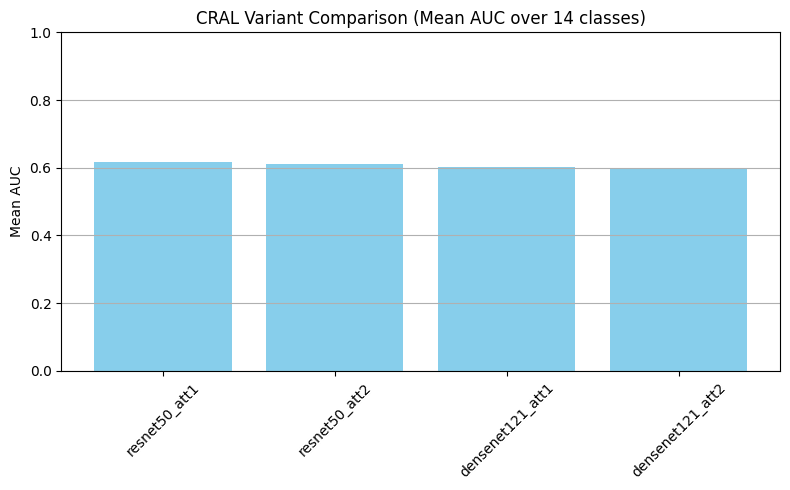

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
labels = list(results.keys())
mean_aucs = [results[k]['mean_auc'] for k in labels]

plt.bar(labels, mean_aucs, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Mean AUC")
plt.title("CRAL Variant Comparison (Mean AUC over 14 classes)")
plt.ylim(0.0, 1.0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Figure 4: ROC Curves for All 4 CRAL Variants

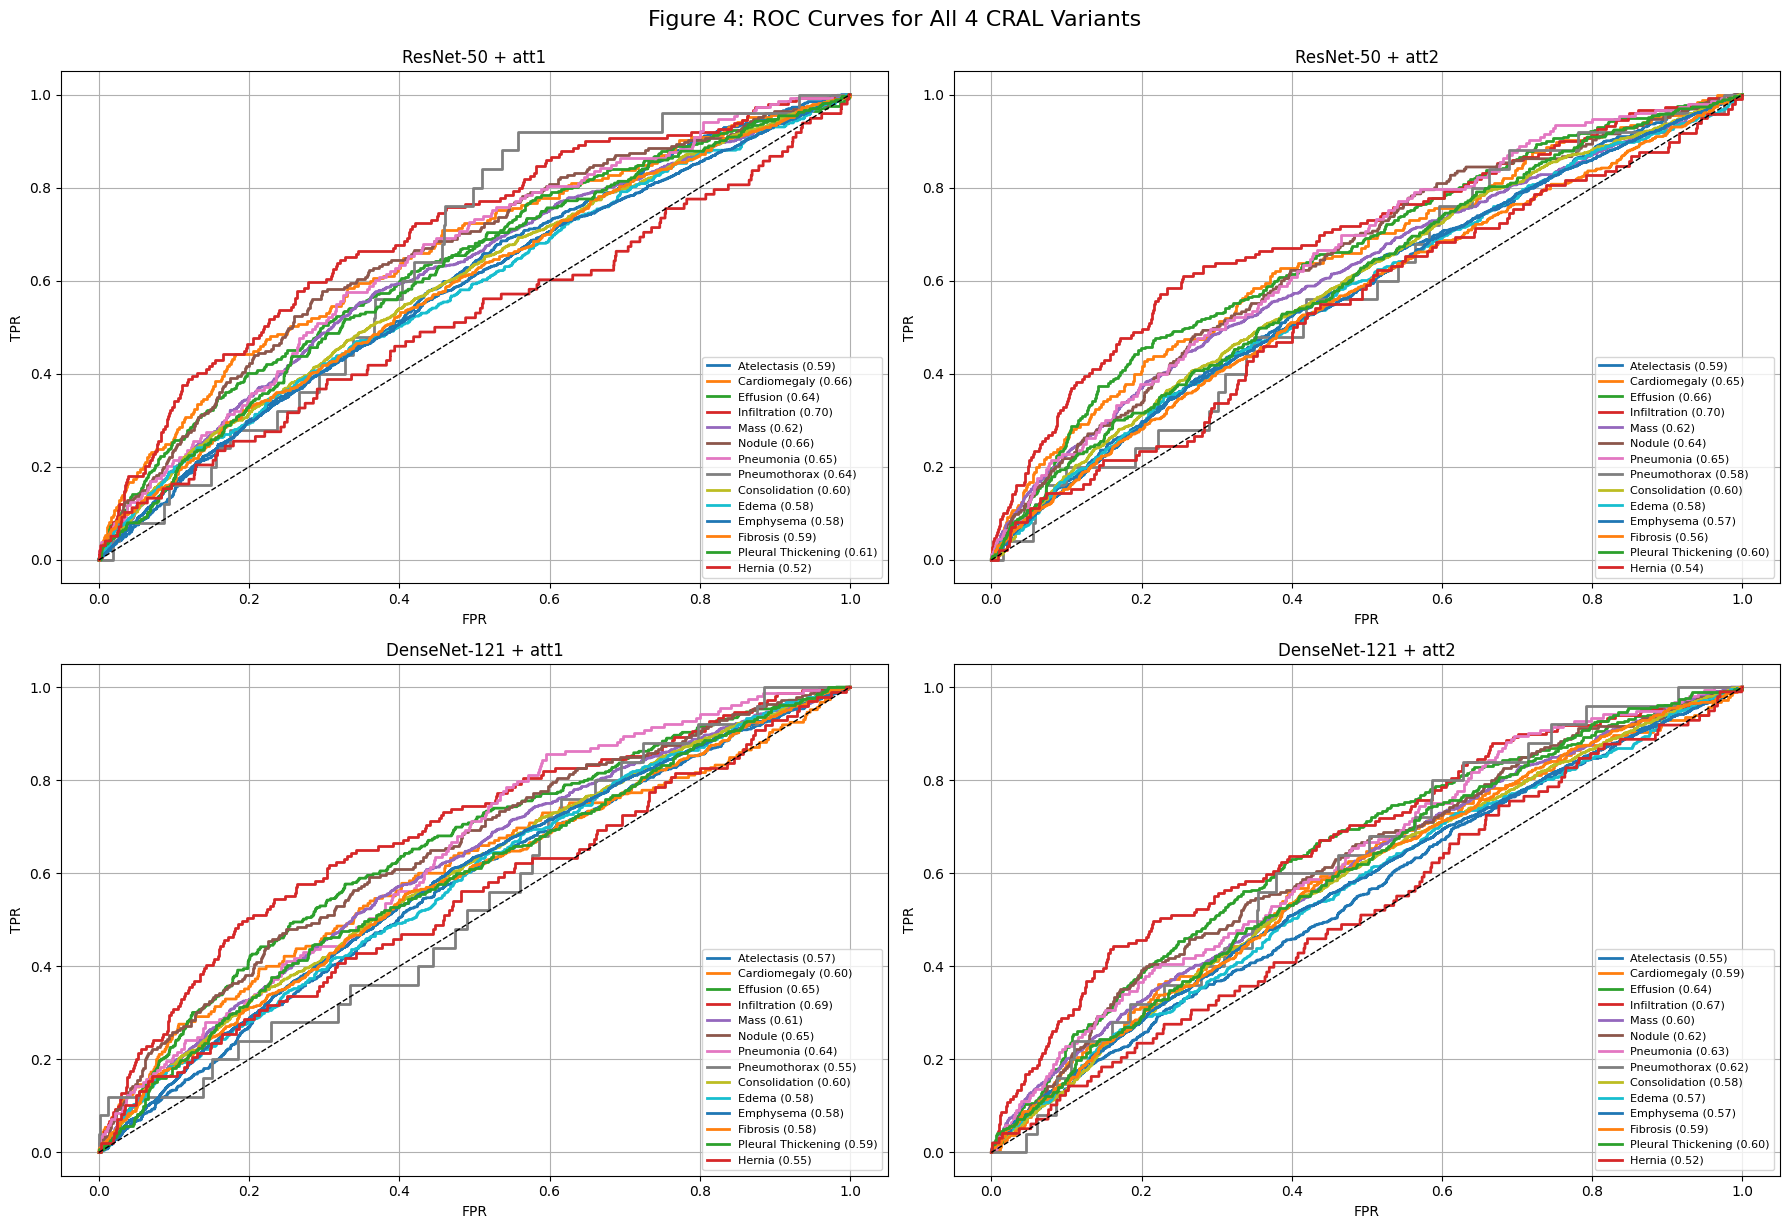

In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

class_labels = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass",
    "Nodule", "Pneumonia", "Pneumothorax", "Consolidation", "Edema",
    "Emphysema", "Fibrosis", "Pleural Thickening", "Hernia"
]

fig, axs = plt.subplots(2, 2, figsize=(18, 12))
axs = axs.flatten()
variant_titles = {
    "resnet50_att1": "ResNet-50 + att1",
    "resnet50_att2": "ResNet-50 + att2",
    "densenet121_att1": "DenseNet-121 + att1",
    "densenet121_att2": "DenseNet-121 + att2"
}

for i, name in enumerate(results.keys()):
    y_true = results[name]["y_true"]
    y_pred = results[name]["y_pred"]
    ax = axs[i]

    for class_idx in range(14):
        try:
            fpr, tpr, _ = roc_curve(y_true[:, class_idx], y_pred[:, class_idx])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f"{class_labels[class_idx]} ({roc_auc:.2f})")
        except:
            continue

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(variant_titles[name], fontsize=12)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True)

plt.tight_layout()
plt.suptitle("Figure 4: ROC Curves for All 4 CRAL Variants", fontsize=16, y=1.02)
plt.show()

# Figure 5: Heatmaps from Attention Maps

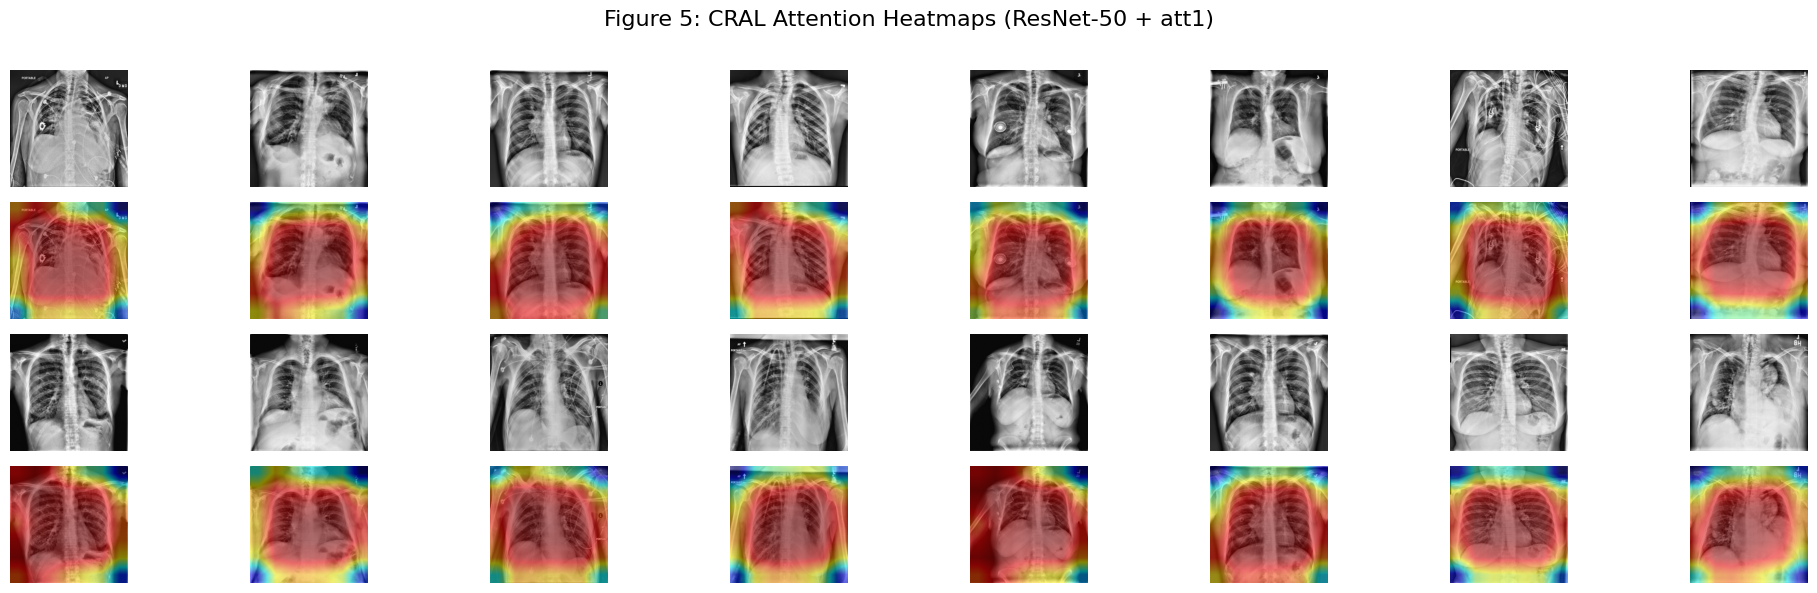

In [107]:
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
import random
from PIL import Image

model = CRAL(num_classes=14, backbone='resnet50', attention_type='att1').to(DEVICE)
model.load_state_dict(torch.load("/kaggle/input/residual_models/pytorch/default/1/resnet50_att1_model.pth", map_location=DEVICE, weights_only=True))
model.eval()

num_cols = 8
num_rows = 2
fig, axs = plt.subplots(num_rows * 2, num_cols, figsize=(20, 6))
fig.suptitle("Figure 5: CRAL Attention Heatmaps (ResNet-50 + att1)", fontsize=16)

with torch.no_grad():
    for i in range(num_cols * num_rows):
        idx = random.randint(0, len(test_ds) - 1)
        image, label = test_ds[idx]
        original_img = Image.open(os.path.join(IMAGE_DIR, test_ds.imgs[idx])).convert("RGB").resize((224, 224))
        original_np = np.array(original_img) / 255.0

        input_tensor = image.unsqueeze(0).to(DEVICE)
        features = model.features(input_tensor)
        attention = model.att(features)  # shape: (1, 14, H, W)

        att_map = attention[0].sum(dim=0)
        att_map = (att_map - att_map.min()) / (att_map.max() - att_map.min() + 1e-8)
        att_map = cv2.resize(att_map.cpu().numpy(), (224, 224))
        heatmap = cv2.applyColorMap(np.uint8(255 * att_map), cv2.COLORMAP_JET)
        heatmap = np.float32(heatmap) / 255.0
        overlay = np.clip(original_np * 0.5 + heatmap * 0.5, 0, 1)

        row = i // num_cols
        col = i % num_cols
        axs[row * 2][col].imshow(original_np)
        axs[row * 2][col].axis('off')
        axs[row * 2 + 1][col].imshow(overlay)
        axs[row * 2 + 1][col].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# Figure 6: Classification Results with Top-8 Predictions

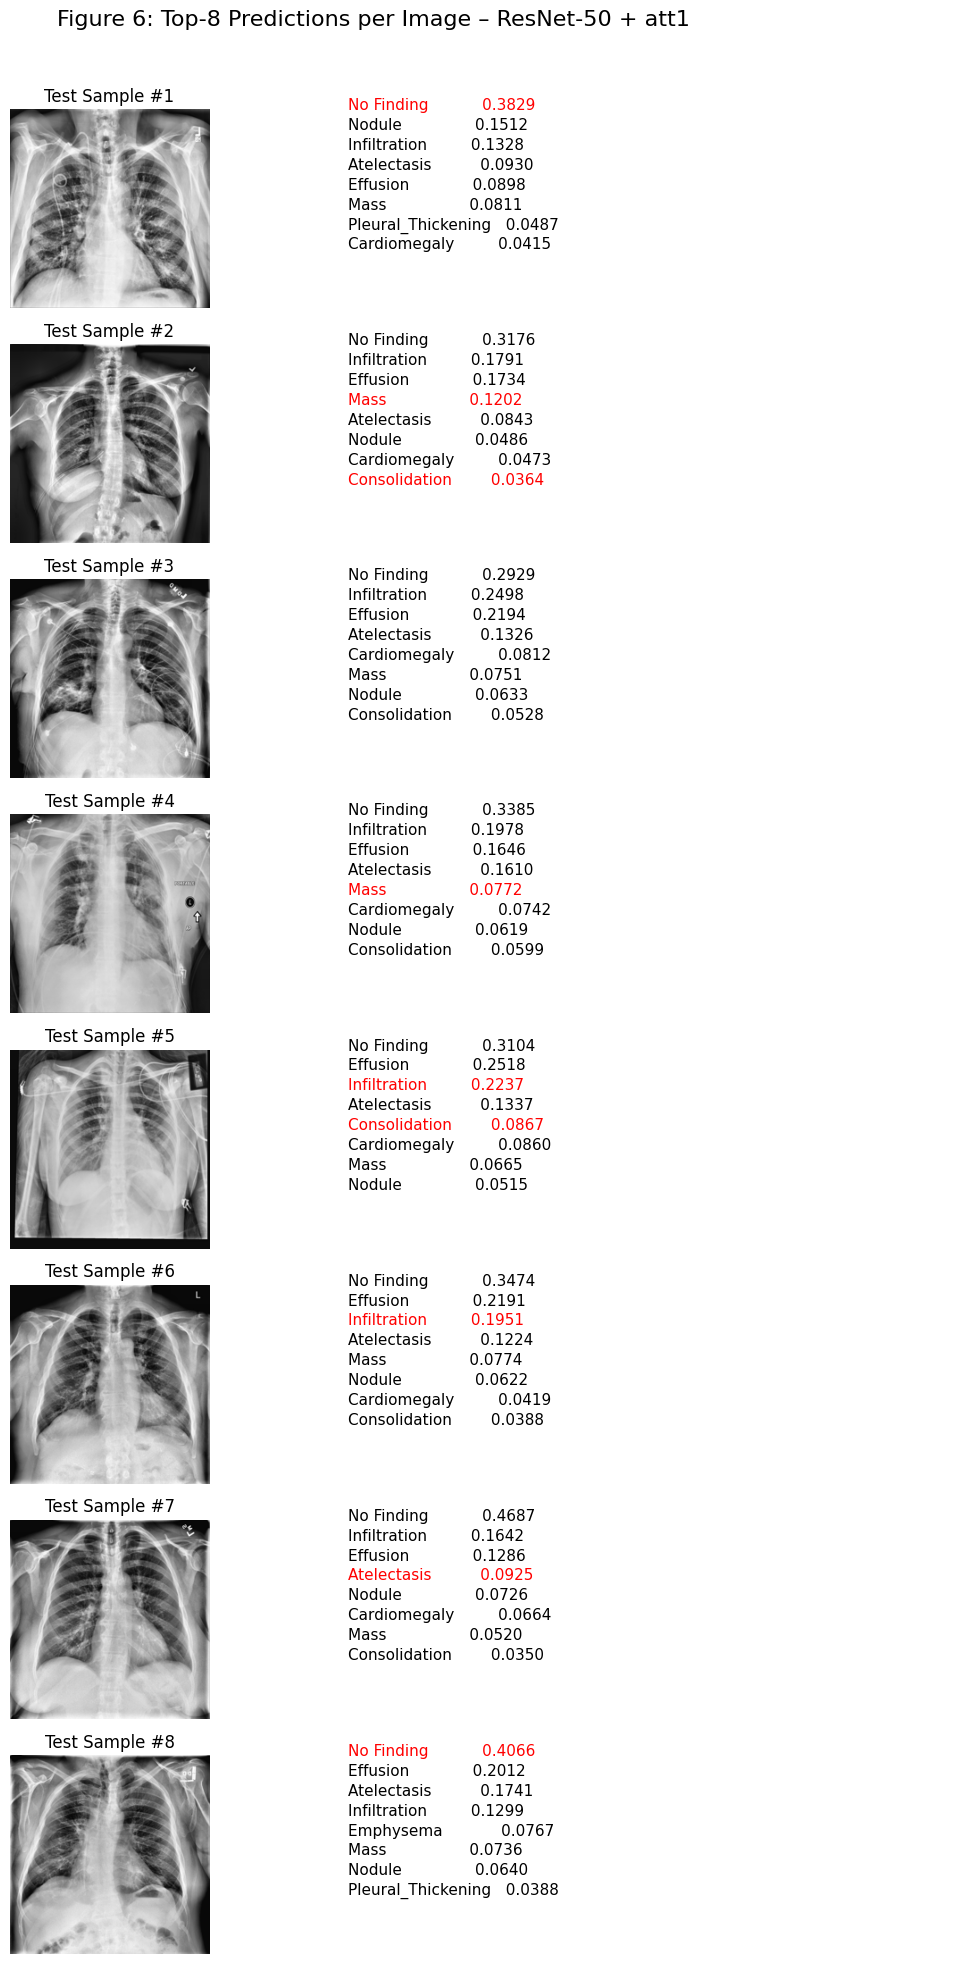

In [106]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
import os
import random

model = CRAL(num_classes=14, backbone='resnet50', attention_type='att1').to(DEVICE)
model.load_state_dict(torch.load("/kaggle/input/residual_models/pytorch/default/1/resnet50_att1_model.pth", map_location=DEVICE, weights_only=True))
model.eval()

class_names = df.columns[1:15].tolist()

num_examples = 8
top_k = 8
fig, axs = plt.subplots(num_examples, 2, figsize=(12, num_examples * 2.5))
fig.suptitle("Figure 6: Top-8 Predictions per Image – ResNet-50 + att1", fontsize=16)

with torch.no_grad():
    for i in range(num_examples):
        idx = random.randint(0, len(test_ds) - 1)
        image, label = test_ds[idx]
        img_path = os.path.join(IMAGE_DIR, test_ds.imgs[idx])
        pil_img = Image.open(img_path).convert("RGB").resize((224, 224))

        input_tensor = image.unsqueeze(0).to(DEVICE)
        output = model(input_tensor).cpu().numpy()[0]

        gt_indices = np.where(label.numpy() == 1)[0]
        pred_indices = np.argsort(output)[::-1][:top_k]

        axs[i, 0].imshow(pil_img, cmap='gray')
        axs[i, 0].axis('off')
        axs[i, 0].set_title(f"Test Sample #{i+1}")

        axs[i, 1].axis('off')
        for j, idx_pred in enumerate(pred_indices):
            label_name = class_names[idx_pred]
            prob = output[idx_pred]
            color = 'red' if idx_pred in gt_indices else 'black'
            axs[i, 1].text(0.05, 1 - 0.1 * j, f"{label_name:<20} {prob:.4f}", color=color, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

# Interpretability

# LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

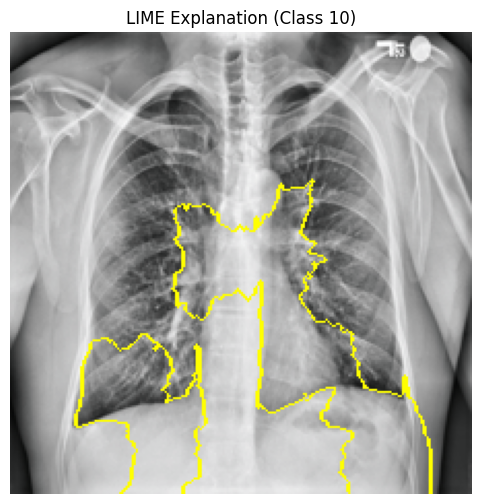

In [98]:
import random
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

i = random.randint(0, len(test_ds) - 1)
img_tensor, label = test_ds[i]
img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

np_img = img_tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
np_img = (np_img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
np_img = (np.clip(np_img, 0, 1) * 255).astype(np.uint8)

def predict(images):
    model.eval()
    tensor_batch = torch.stack([
        test_transform(Image.fromarray(img)).to(DEVICE) for img in images
    ])
    with torch.no_grad():
        outputs = model(tensor_batch)
    return outputs.detach().cpu().numpy()

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    np_img,
    predict,
    top_labels=1,         
    num_features=8,
    num_samples=1000
)

pred_label = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(pred_label, positive_only=True, hide_rest=False)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Explanation (Class {pred_label})")
plt.axis("off")
plt.show()

# Grad-CAM

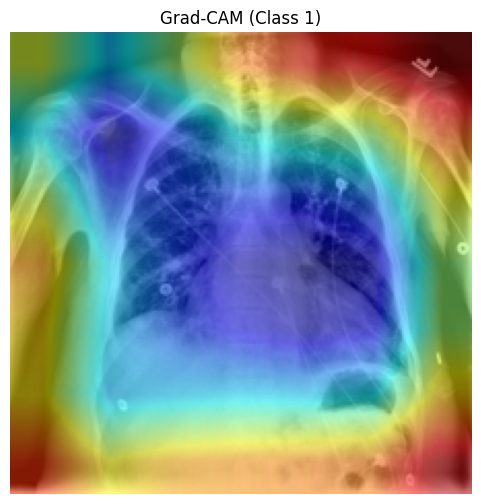

In [99]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image
import random

idx = random.randint(0, len(test_ds) - 1)
img_tensor, label = test_ds[idx]
img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

img_np = img_tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
img_np = np.clip(img_np, 0, 1)

class_idx = 1

gradients = []
activations = []

def save_activation(module, input, output):
    activations.append(output)

def save_gradient(module, grad_input, grad_output):
    gradients.append(grad_output[0])

for name, module in model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        last_conv = module
last_conv.register_forward_hook(save_activation)
last_conv.register_full_backward_hook(save_gradient)

model.eval()
output = model(img_tensor)
model.zero_grad()
output[0, class_idx].backward()

act = activations[0]        # (B, C, H, W)
grad = gradients[0]         # (B, C, H, W)
weights = grad.mean(dim=(2, 3), keepdim=True)
cam = F.relu((weights * act).sum(dim=1)).squeeze().detach().cpu().numpy()
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)
cam = cv2.resize(cam, (224, 224))
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = np.clip(heatmap / 255.0 * 0.5 + img_np * 0.5, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.title(f"Grad-CAM (Class {class_idx})")
plt.axis("off")
plt.show()

# DeepDream

Iteration 0, Loss: 258.8856
Iteration 10, Loss: 259.3295
Iteration 20, Loss: 259.7666


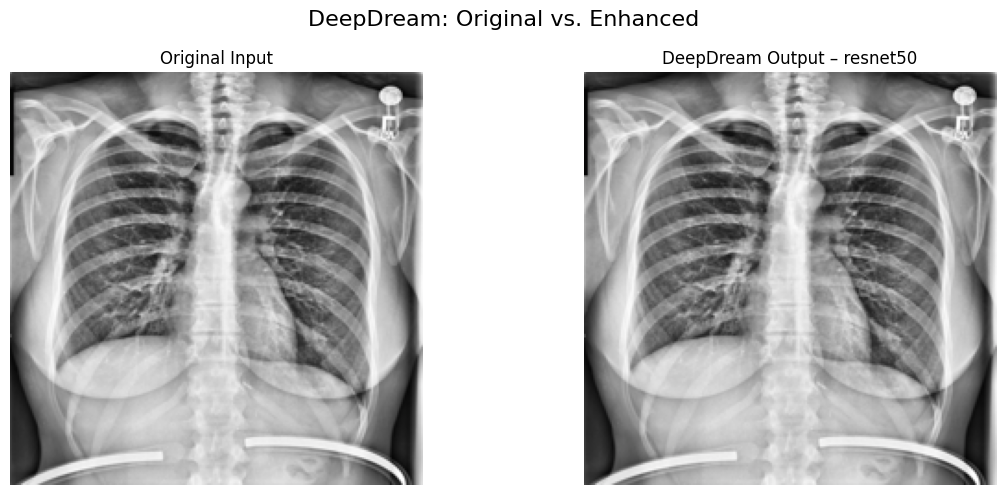

In [100]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import random

if model.backbone_type == 'resnet50':
    dream_model = nn.Sequential(
        model.features[0],   # conv1
        model.features[1],   # bn1
        model.features[2],   # relu
        model.features[3],   # maxpool
        model.features[4]    # layer1
    ).to(DEVICE).eval()
    
elif model.backbone_type == 'densenet121':
    dream_model = nn.Sequential(
        model.features[0],   # conv0
        model.features[1],   # norm0
        model.features[2],   # relu0
        model.features[3],   # pool0
        model.features[4]    # denseblock1
    ).to(DEVICE).eval()
else:
    raise ValueError("Unsupported backbone for DeepDream")

def deprocess(tensor):
    img = tensor.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    img = (img * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    return np.clip(img, 0, 1)

# === DeepDream logic ===
def deepdream(image, model, iterations=30, lr=0.01):
    image = image.clone().detach().to(DEVICE).requires_grad_(True)
    for i in range(iterations):
        try:
            model.zero_grad()
            out = model(image)
            loss = out.norm()
            loss.backward()
            image.data += lr * image.grad.data
            image.grad.data.zero_()
            if i % 10 == 0:
                print(f"Iteration {i}, Loss: {loss.item():.4f}")
        except Exception as e:
            print(f"DeepDream error at iteration {i}: {e}")
            break
    return image.detach()

i = random.randint(0, len(test_ds) - 1)
img_tensor, label = test_ds[i]
input_tensor = img_tensor.unsqueeze(0)

dreamed = deepdream(input_tensor, dream_model)

original_img = deprocess(input_tensor)
dreamed_img = deprocess(dreamed)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dreamed_img)
plt.title(f"DeepDream Output – {model.backbone_type}")
plt.axis("off")

plt.suptitle("DeepDream: Original vs. Enhanced", fontsize=16)
plt.tight_layout()
plt.show()

# SHAP

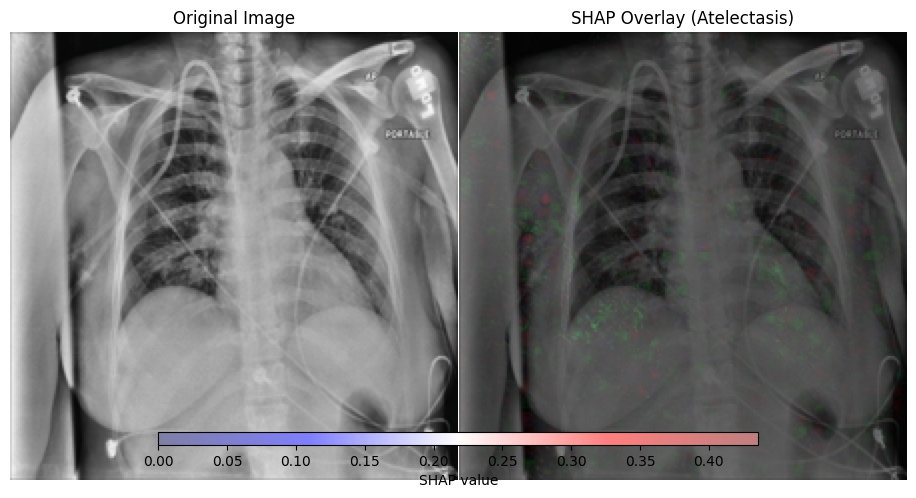

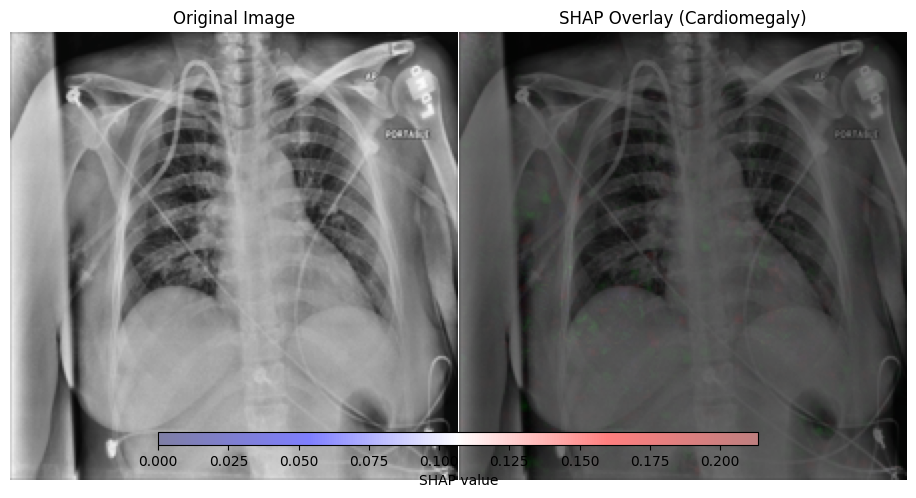

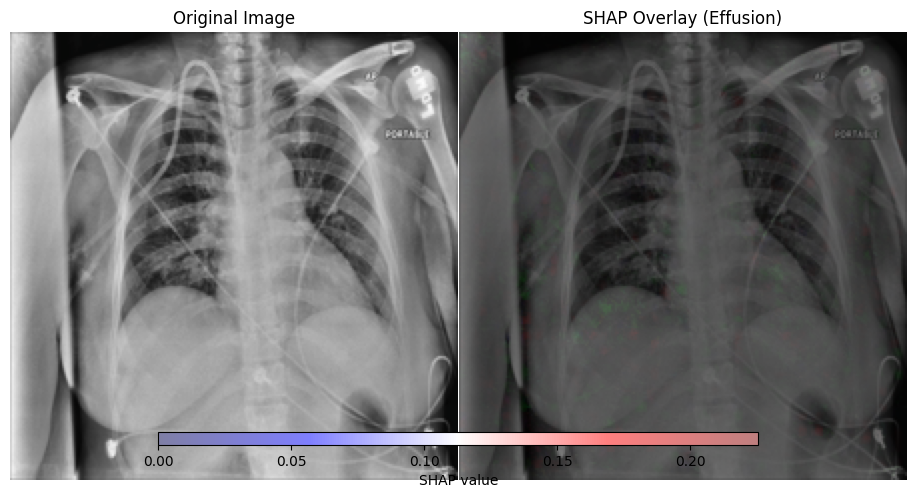

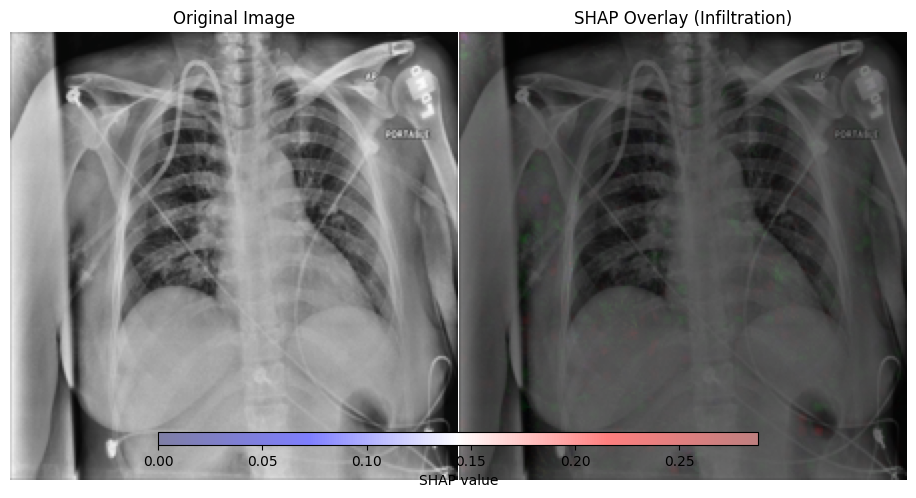

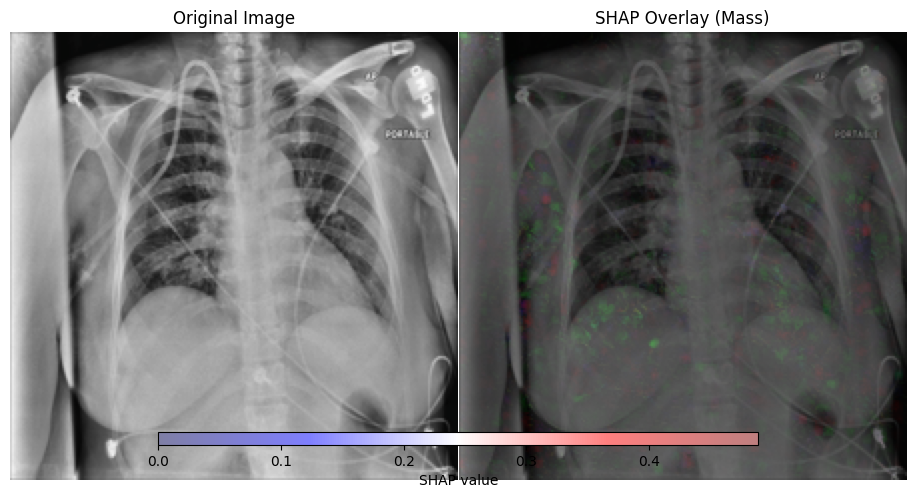

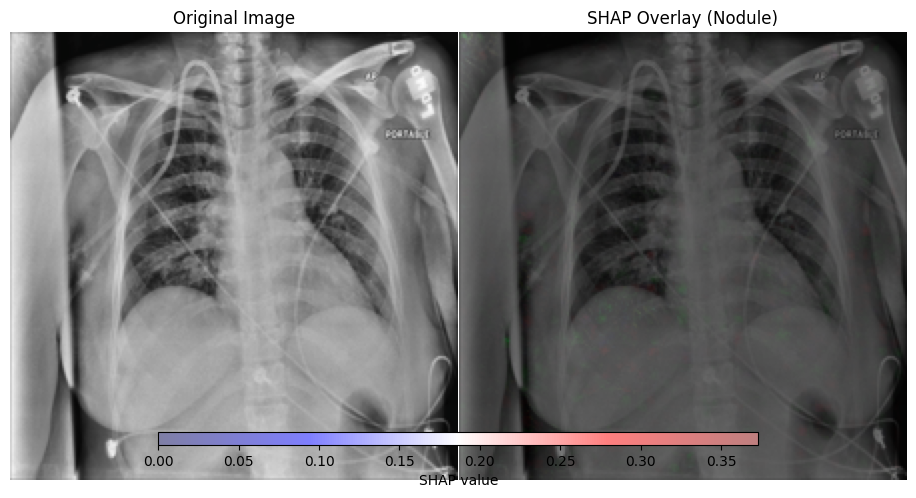

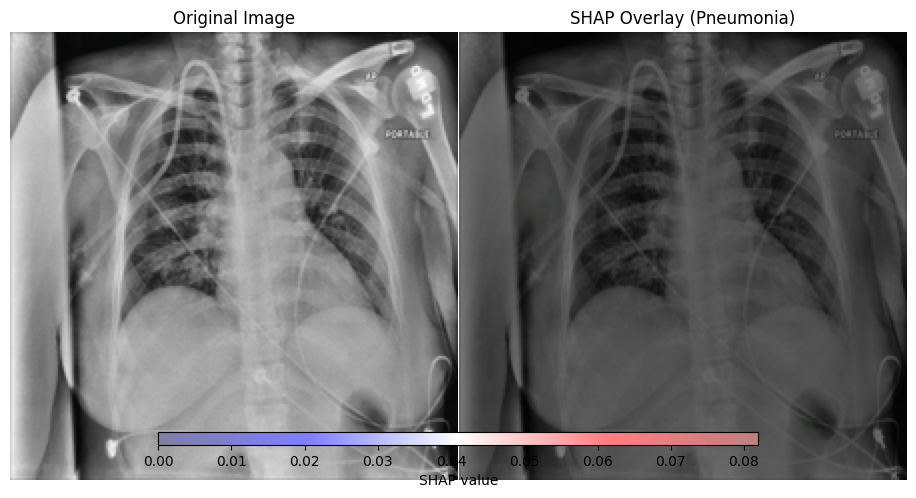

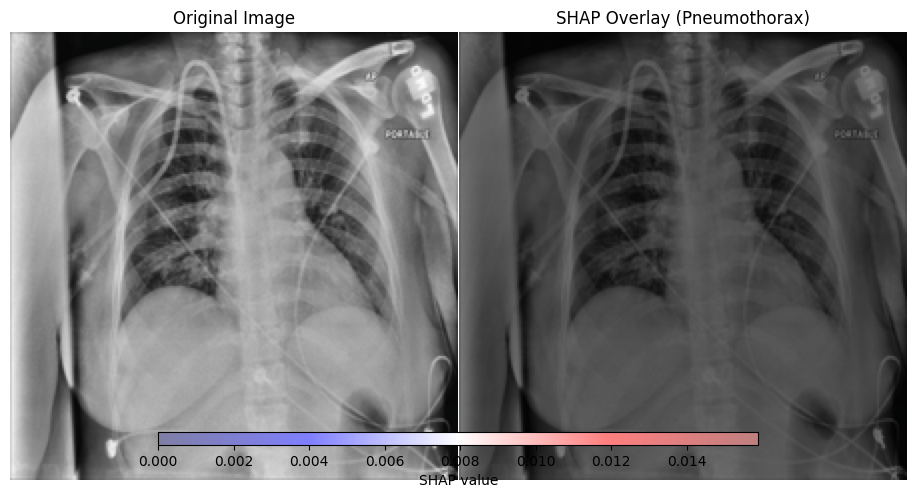

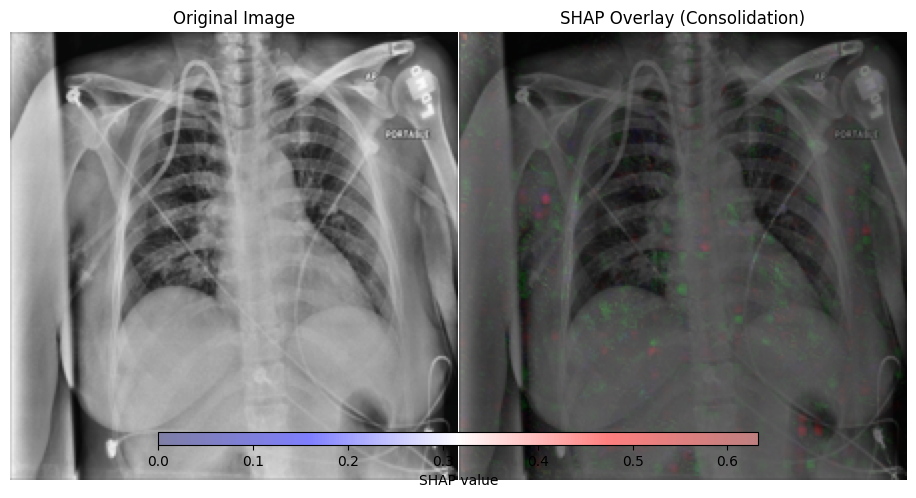

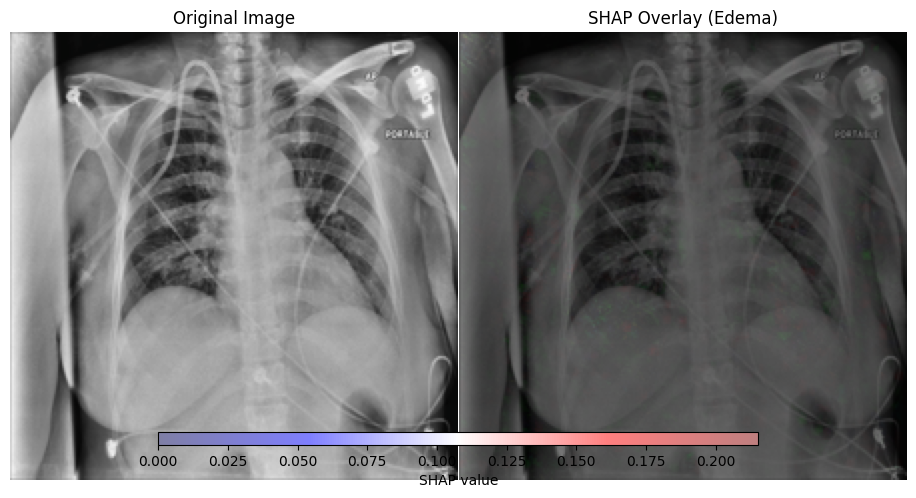

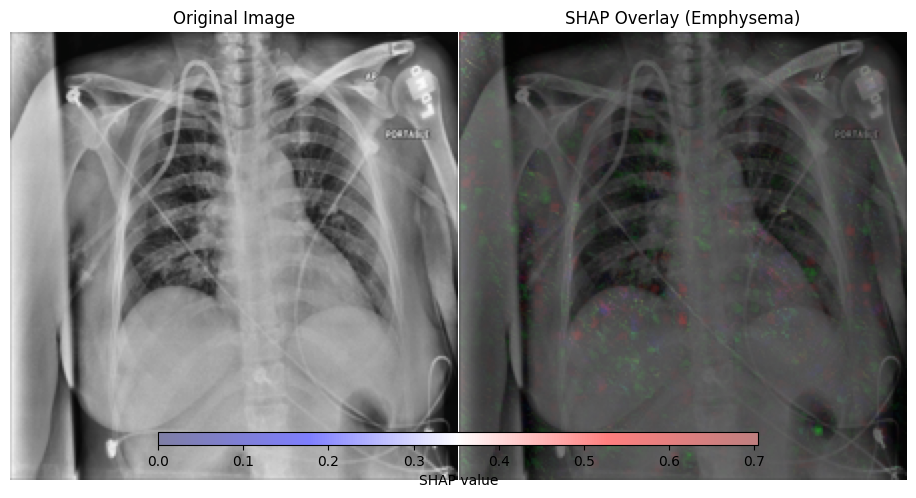

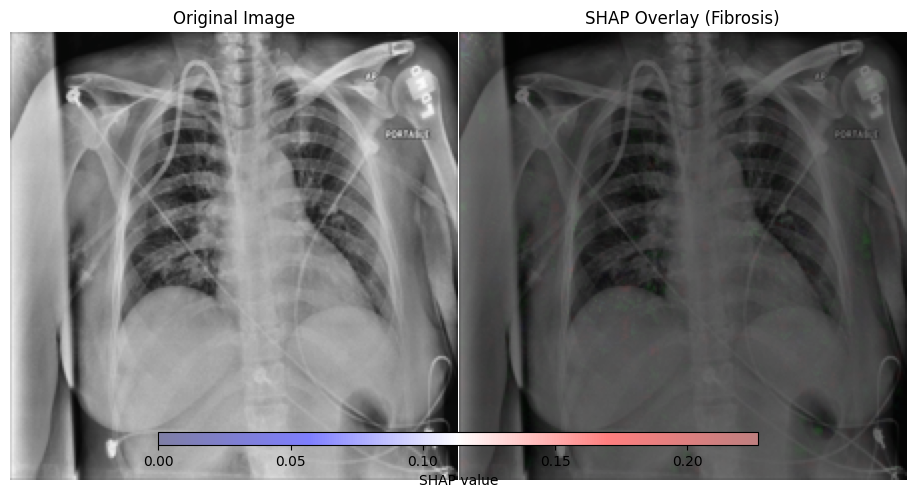

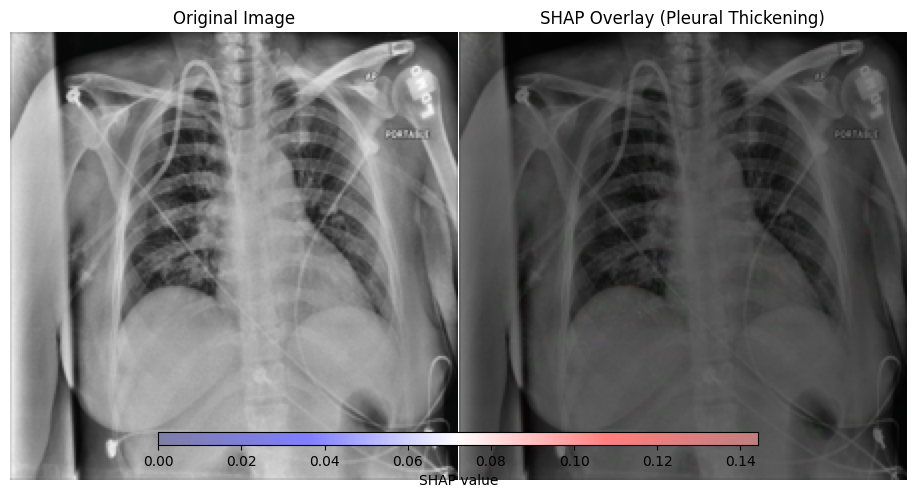

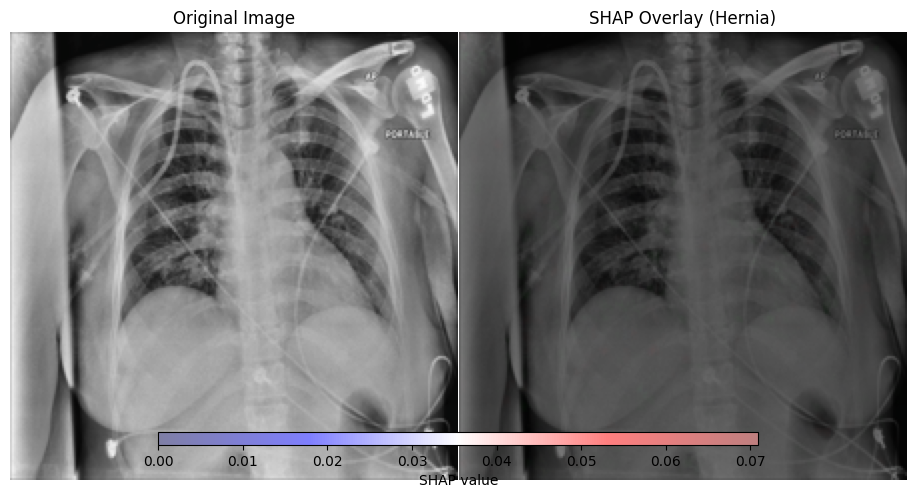

In [124]:
import shap
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

model = CRAL(num_classes=14, backbone='resnet50', attention_type='att1').to(DEVICE)
model.load_state_dict(torch.load(
    "/kaggle/input/residual_models/pytorch/default/1/resnet50_att1_model.pth",
    map_location=DEVICE,
    weights_only=True
))
model.eval()

i = random.randint(0, len(test_ds) - 1)
img_tensor, label = test_ds[i]
img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

background = torch.cat([
    test_ds[j][0].unsqueeze(0)
    for j in random.sample(range(len(test_ds)), 3)
]).to(DEVICE)

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(img_tensor)

img_np = img_tensor.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
img_np = np.clip(img_np, 0, 1)

class_names = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass",
    "Nodule", "Pneumonia", "Pneumothorax", "Consolidation", "Edema",
    "Emphysema", "Fibrosis", "Pleural Thickening", "Hernia"
]

for idx in range(14):
    shap_map = shap_values[idx][0].transpose(1, 2, 0) * 200
    shap_map = np.clip(shap_map, -1, 1)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 1]})

    axs[0].imshow(img_np)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(img_np)
    im = axs[1].imshow(shap_map, cmap="seismic", alpha=0.5)
    axs[1].set_title(f"SHAP Overlay ({class_names[idx]})")
    axs[1].axis("off")

    cbar_ax = fig.add_axes([0.2, 0.1, 0.6, 0.025])  # moved to fit in expanded space
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("SHAP value")

    plt.subplots_adjust(bottom=0.35)
    plt.tight_layout()
    plt.show()

In [ ]:
# !zip -r model_outputs.zip /kaggle/working/*.pth /kaggle/working/*.npz